# Hw2.2 - Аналіз опитування розробників (2017)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Прочитайте файл 2017_jun_final.csv

In [2]:
df = pd.read_csv('2017_jun_final - 2017_jun_final.csv')

## 2. Виведіть перші рядки таблиці

In [3]:
df.head()

,N,Посада,Мова програмування,Спеціалізація,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,...,Ще студент,Рівень англійської,Предметна область,Дата заповнення,User.Agent,exp,current_job_exp,salary,Валюта,cls
0,1,Junior QA engineer,NaN,Manual QA,0.5,0.5,400,0,Харків,до 10 осіб,...,True,Pre-intermediate (нище середнього),"iOS,eCommerce",12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400,NaN,QA
1,2,Junior QA engineer,NaN,Manual QA,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,...,True,Upper-Intermediate (вище середнього),Веб-розробка,12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430,NaN,QA
2,3,Software Engineer,C#/.NET,NaN,4,1,2500,800,Київ,до 1000 осіб,...,False,Intermediate (середній),"Веб-розробка,Корпоративні системи",12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500,NaN,DEV
3,4,Software Engineer,JavaScript,NaN,5,4,2000,400,Одеса,до 200 осіб,...,False,Pre-intermediate (нище середнього),"Desktop Applications,Веб-розробка",12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000,NaN,DEV
4,5,Senior Software Engineer,JavaScript,NaN,10 і більше років,0.5,4500,500,Інше,до 10 осіб,...,False,Intermediate (середній),"Desktop Applications,Веб-розробка",12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500,NaN,DEV


## 3. Визначте розмір таблиці

In [4]:
df.shape

(8704, 25)

## 4. Визначте типи всіх стовпців

In [5]:
df.dtypes

N                                     int64
Посада                                  str
Мова програмування                      str
Спеціалізація                           str
Загальний досвід роботи                 str
Досвід роботи на поточному місці        str
Зарплата на місяць                    int64
Зміна зарплати за 12 місяців          int64
Місто                                   str
Розмір компанії                         str
Тип компанії                            str
Стать                                   str
Вік                                   int64
Освіта                                  str
Університет                             str
Ще студент                             bool
Рівень англійської                      str
Предметна область                       str
Дата заповнення                         str
User.Agent                              str
exp                                 float64
current_job_exp                     float64
salary                          

## 5. Порахуйте частку пропусків в кожній колонці

In [6]:
missing_pct = df.isnull().sum() / len(df) * 100
missing_pct

N                                    0.000000
Посада                               0.000000
Мова програмування                  44.232537
Спеціалізація                       82.938879
Загальний досвід роботи              0.000000
Досвід роботи на поточному місці     0.000000
Зарплата на місяць                   0.000000
Зміна зарплати за 12 місяців         0.000000
Місто                                0.000000
Розмір компанії                      0.000000
Тип компанії                         0.000000
Стать                                0.000000
Вік                                  0.000000
Освіта                               0.000000
Університет                          4.113051
Ще студент                           0.000000
Рівень англійської                   0.000000
Предметна область                    2.562040
Дата заповнення                      0.000000
User.Agent                           0.000000
exp                                  0.000000
current_job_exp                   

## 6. Видаліть усі стовпці з пропусками, крім стовпця "Мова програмування"

In [7]:
lang_col = 'Мова програмування'
cols_to_drop = [c for c in df.columns if df[c].isnull().any() and c != lang_col]
df_cleaned = df.drop(columns=cols_to_drop)
print(f'Видалені стовпці: {cols_to_drop}')
df_cleaned.head()

Видалені стовпці: ['Спеціалізація', 'Університет', 'Предметна область', 'Валюта', 'cls']


,N,Посада,Мова програмування,Загальний досвід роботи,Досвід роботи на поточному місці,Зарплата на місяць,Зміна зарплати за 12 місяців,Місто,Розмір компанії,Тип компанії,Стать,Вік,Освіта,Ще студент,Рівень англійської,Дата заповнення,User.Agent,exp,current_job_exp,salary
0,1,Junior QA engineer,NaN,0.5,0.5,400,0,Харків,до 10 осіб,Аутсорсингова,жіноча,20,Неповна Вища,True,Pre-intermediate (нище середнього),12/06/2017 12:38:08,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0.5,0.5,400
1,2,Junior QA engineer,NaN,менше 3 місяців,менше 3 місяців,430,130,Харків,більше 1000 осіб,Аутсорсингова,жіноча,21,Неповна Вища,True,Upper-Intermediate (вище середнього),12/06/2017 12:42:51,Mozilla/5.0 (iPad; CPU OS 10_2_1 like Mac OS X...,0.0,0.0,430
2,3,Software Engineer,C#/.NET,4,1,2500,800,Київ,до 1000 осіб,Аутсорсингова,чоловіча,26,Вища,False,Intermediate (середній),12/06/2017 13:02:47,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,4.0,1.0,2500
3,4,Software Engineer,JavaScript,5,4,2000,400,Одеса,до 200 осіб,Продуктова,чоловіча,30,Середня,False,Pre-intermediate (нище середнього),12/06/2017 13:03:01,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,5.0,4.0,2000
4,5,Senior Software Engineer,JavaScript,10 і більше років,0.5,4500,500,Інше,до 10 осіб,Продуктова,чоловіча,30,Технікум / Коледж,False,Intermediate (середній),12/06/2017 13:03:47,Mozilla/5.0 (iPhone; CPU iPhone OS 10_3_2 like...,10.0,0.5,4500


## 7. Перевірте залишкові пропуски

In [8]:
missing_after = df_cleaned.isnull().sum() / len(df_cleaned) * 100
missing_after

N                                    0.000000
Посада                               0.000000
Мова програмування                  44.232537
Загальний досвід роботи              0.000000
Досвід роботи на поточному місці     0.000000
Зарплата на місяць                   0.000000
Зміна зарплати за 12 місяців         0.000000
Місто                                0.000000
Розмір компанії                      0.000000
Тип компанії                         0.000000
Стать                                0.000000
Вік                                  0.000000
Освіта                               0.000000
Ще студент                           0.000000
Рівень англійської                   0.000000
Дата заповнення                      0.000000
User.Agent                           0.000000
exp                                  0.000000
current_job_exp                      0.000000
salary                               0.000000
dtype: float64

## 8. Видаліть усі рядки з пропусками

In [9]:
df_cleaned = df_cleaned.dropna()
df_cleaned.shape

(4854, 20)

## 9. Визначте новий розмір таблиці

In [10]:
df_cleaned.shape

(4854, 20)

## 10. Створіть таблицю python_data

In [11]:
python_data = df_cleaned[df_cleaned[lang_col].str.contains('Python', case=False, na=False)].copy()
python_data.shape

(207, 20)

## 11. Групування за стовпчиком "Посада"

In [12]:
job_col = 'Посада'
salary_col = 'Зарплата на місяць'

grouped = python_data.groupby(job_col)
grouped.size()

Посада
Junior Software Engineer     63
Senior Software Engineer     31
Software Engineer           100
System Architect              2
Technical Lead               11
dtype: int64

## 12. Агрегація даних (min та max зарплати)

In [13]:
agg_df = python_data.groupby(job_col)[salary_col].agg(['min', 'max'])
agg_df

,min,max
Посада,,
Junior Software Engineer,100,1250
Senior Software Engineer,1300,9200
Software Engineer,500,5400
System Architect,3000,5000
Technical Lead,1425,6200


## 13. Функція для середньої зарплати та стовпчик "avg"

In [14]:
def fill_avg_salary(title):
    return python_data[python_data[job_col] == title][salary_col].mean()

python_data['avg'] = python_data[job_col].apply(fill_avg_salary)
python_data[['Посада', 'Зарплата на місяць', 'avg']].head(10)

,Посада,Зарплата на місяць,avg
12,Software Engineer,800,1799.07000
68,Software Engineer,900,1799.07000
87,Junior Software Engineer,600,560.84127
114,Junior Software Engineer,685,560.84127
143,Junior Software Engineer,750,560.84127
153,Software Engineer,1200,1799.07000
162,Junior Software Engineer,500,560.84127
171,Junior Software Engineer,800,560.84127
217,Software Engineer,2900,1799.07000
283,Junior Software Engineer,400,560.84127


## 14. Описова статистика для стовпчика "avg"

In [15]:
python_data['avg'].describe()

count     207.000000
mean     1753.937198
std       996.562606
min       560.841270
25%       560.841270
50%      1799.070000
75%      1799.070000
max      4000.000000
Name: avg, dtype: float64

## 15. Збереження в CSV файл

In [16]:
python_data.to_csv('python_developers_analysis.csv', index=False)
print('Data saved to python_developers_analysis.csv')

Data saved to python_developers_analysis.csv


## Графік 1: Кількість Python розробників за посадою

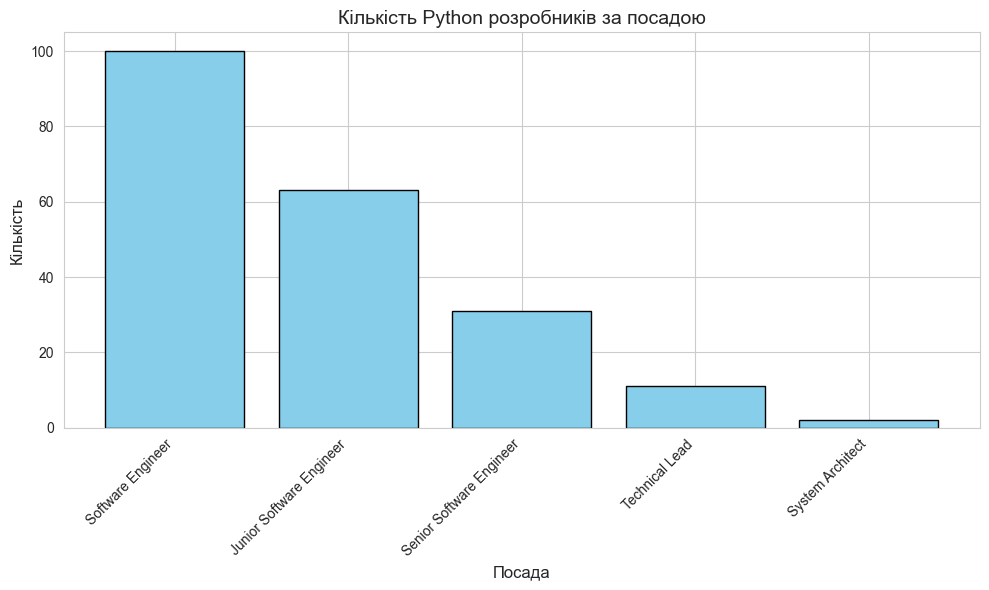

In [17]:
plt.figure(figsize=(10, 6))
position_counts = python_data['Посада'].value_counts()
plt.bar(position_counts.index, position_counts.values, color='skyblue', edgecolor='black')
plt.title('Кількість Python розробників за посадою', fontsize=14)
plt.xlabel('Посада', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Графік 2: Boxplot зарплати за посадою

C:\Users\e4493\AppData\Local\Temp\ipykernel_1348\1689257087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=python_data, x='Посада', y='Зарплата на місяць', palette='Set2')


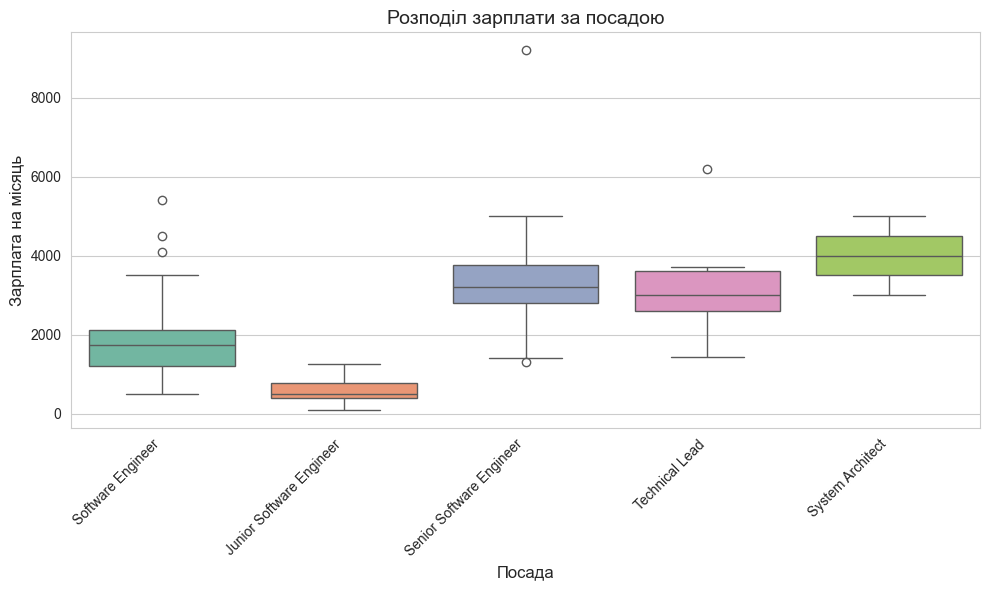

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=python_data, x='Посада', y='Зарплата на місяць', palette='Set2')
plt.title('Розподіл зарплати за посадою', fontsize=14)
plt.xlabel('Посада', fontsize=12)
plt.ylabel('Зарплата на місяць', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Графік 3: Гістограма розподілу зарплат

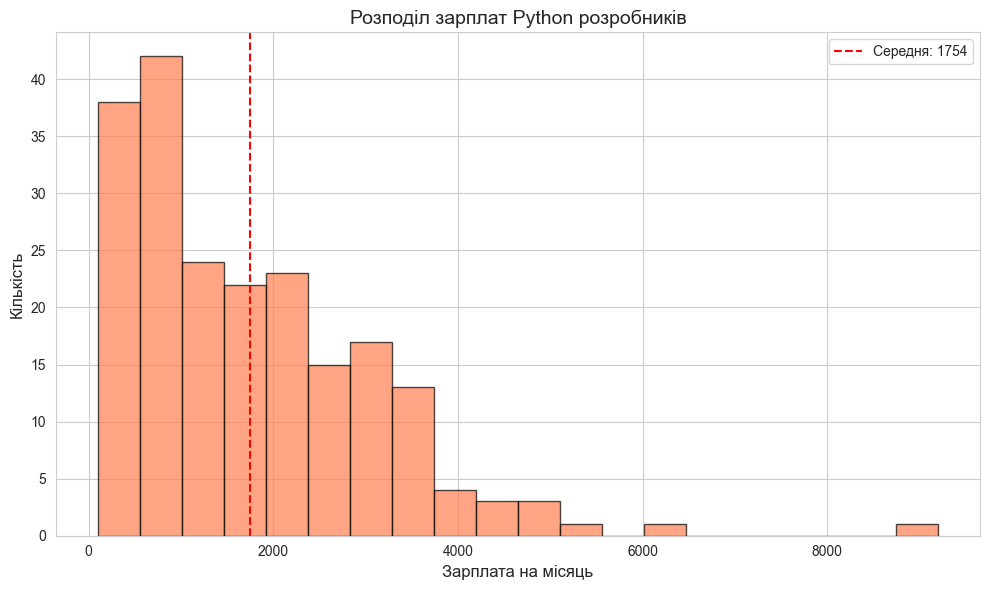

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(python_data['Зарплата на місяць'], bins=20, color='coral', edgecolor='black', alpha=0.7)
plt.title('Розподіл зарплат Python розробників', fontsize=14)
plt.xlabel('Зарплата на місяць', fontsize=12)
plt.ylabel('Кількість', fontsize=12)
plt.axvline(python_data['Зарплата на місяць'].mean(), color='red', linestyle='--', label=f'Середня: {python_data["Зарплата на місяць"].mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

## Графік 4: Порівняння min, max та середньої зарплати

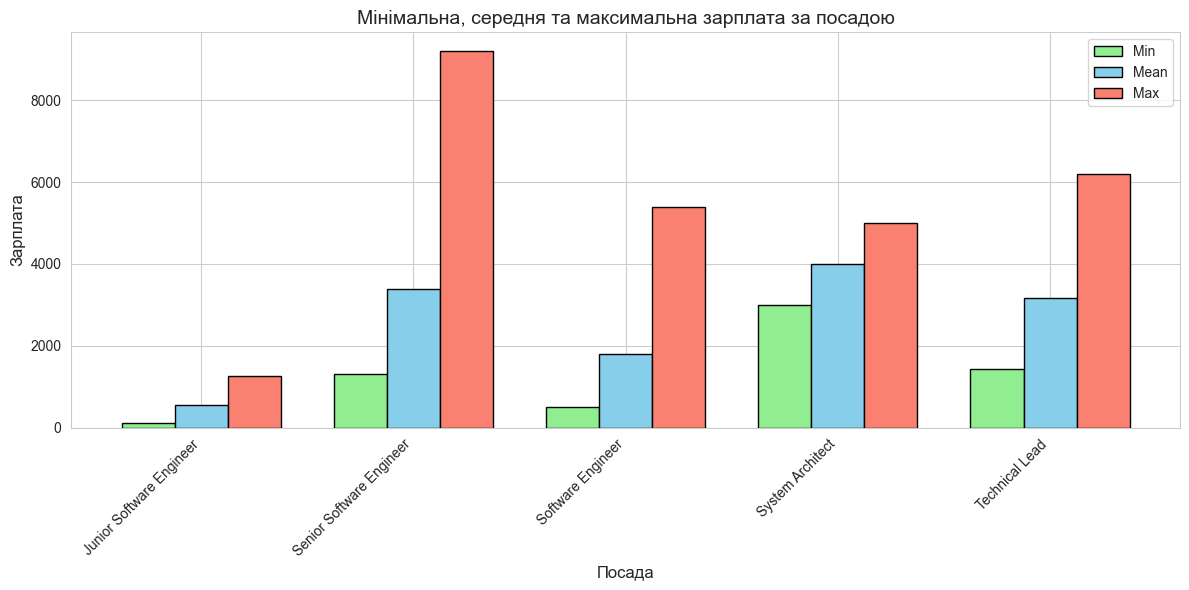

In [20]:
agg_full = python_data.groupby('Посада')['Зарплата на місяць'].agg(['min', 'max', 'mean']).reset_index()

x = np.arange(len(agg_full['Посада']))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, agg_full['min'], width, label='Min', color='lightgreen', edgecolor='black')
bars2 = ax.bar(x, agg_full['mean'], width, label='Mean', color='skyblue', edgecolor='black')
bars3 = ax.bar(x + width, agg_full['max'], width, label='Max', color='salmon', edgecolor='black')

ax.set_xlabel('Посада', fontsize=12)
ax.set_ylabel('Зарплата', fontsize=12)
ax.set_title('Мінімальна, середня та максимальна зарплата за посадою', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(agg_full['Посада'], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Графік 5: Scatter plot зарплати та avg з кольором за посадою

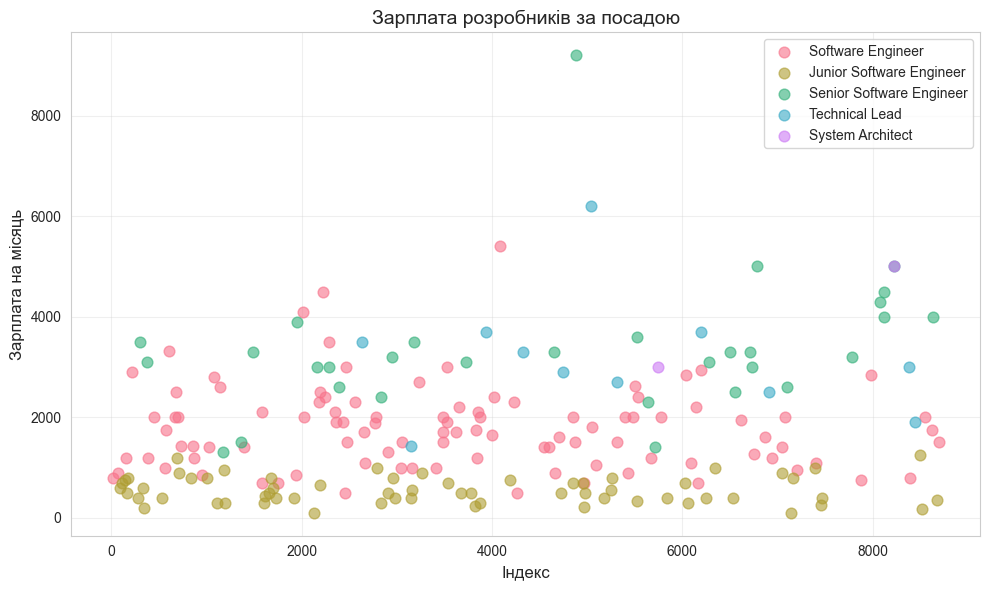

In [21]:
plt.figure(figsize=(10, 6))
positions = python_data['Посада'].unique()
colors = sns.color_palette('husl', len(positions))

for i, pos in enumerate(positions):
    subset = python_data[python_data['Посада'] == pos]
    plt.scatter(subset.index, subset['Зарплата на місяць'], 
               c=[colors[i]], label=pos, alpha=0.6, s=60)

plt.title('Зарплата розробників за посадою', fontsize=14)
plt.xlabel('Індекс', fontsize=12)
plt.ylabel('Зарплата на місяць', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()